# 12 — Third-Person Prompt Experiment

**Hypothesis:** Rewriting the agent persona from first-person ("I am a 55-year-old...") to
third-person observer framing ("You are simulating a survey respondent: A 55-year-old...")
reduces the systematic pro-climate bias found in notebook 11.

**Design:** A/B test with two conditions:
- **1P (control):** Current first-person system prompt + user prompt (identical to notebook 11)
- **3P (treatment):** Third-person system prompt + "How would this person respond?" user prompt

Both conditions are applied to the same N agents × M models, using `send_chat()` directly
(no source code changes).

**References:**
- ELEPHANT (Cheng et al. 2025, arXiv:2505.13995)
- SimToM (Wilf et al. 2023, arXiv:2311.10227)
- ~15pp sycophancy reduction reported in the literature

In [1]:
# ── Imports ──
import sys, os, logging, time, random
import pandas as pd
import numpy as np
from datetime import date, datetime
from statistics import mean, stdev
from collections import Counter
from scipy.stats import spearmanr, wilcoxon

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from cag.io.survey import load
from cag.io.llm import load_api_key, send_chat, parse_letter_response
from cag.abm.agent import SurveyedCitizen
from cag.abm.environment import SurveyedNation
from cag.abm.attributes.opinion import (
    ClimatePolicyID, SURVEY_COLUMN_MAP, SURVEY_QUESTIONS,
    RESPONSE_SCALE, RESPONSE_LABELS, ordinal_score,
)

from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
)

logging.basicConfig(level=logging.WARNING)
print("Imports OK")

Imports OK


## Configuration

Three models selected based on notebook 11 results:
- **gemini-2.5-flash** — fast/cheap baseline
- **gemini-3.1-pro** — best signed error (+0.73) from notebook 11
- **claude-sonnet-4-6** — best MAE (1.80), best Spearman ρ (0.437) from notebook 11

Total API calls: 3 models × 2 conditions × 30 agents = **180 calls**.

In [2]:
# ── Experiment config ──
MODELS = [
    # ("gemini-2.5-flash",   "gemini-2.5-flash",       "genai"),
    ("gemini-3.1-pro",     "gemini-3.1-pro-preview",  "genai"),
    ("claude-sonnet-4-6",  "claude-sonnet-4-6",       "anthropic"),
]

CONDITIONS = ["1P", "3P"]  # first-person (control) vs third-person (treatment)

POLICY_ID = ClimatePolicyID.BAN_PETROL_CARS
N_AGENTS = 30
TEMPERATURE = 0.5
THINKING = True
RANDOM_SEED = 44  # same seed as notebook 11 for comparability

# Load API keys
api_keys = {}
for _, _, provider in MODELS:
    if provider not in api_keys:
        api_keys[provider] = load_api_key(provider)

print(f"Policy: {POLICY_ID}")
print(f"Agents: {N_AGENTS}, Seed: {RANDOM_SEED}, Temperature: {TEMPERATURE}, Thinking: {THINKING}")
print(f"Models: {[name for name, _, _ in MODELS]}")
print(f"Conditions: {CONDITIONS}")
print(f"Total API calls: {len(MODELS) * len(CONDITIONS) * N_AGENTS}")
print(f"API keys loaded for: {list(api_keys.keys())}")

Policy: ClimatePolicyID(3)
Agents: 30, Seed: 44, Temperature: 0.5, Thinking: True
Models: ['gemini-3.1-pro', 'claude-sonnet-4-6']
Conditions: ['1P', '3P']
Total API calls: 120
API keys loaded for: ['genai', 'anthropic']


## Build environment and sample agents

In [3]:
# ── Build the SurveyedNation and sample agents ──
random.seed(RANDOM_SEED)
year = 2026

UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)

sn = SurveyedNation(
    year=year, place="UK",
    gender_map=GenderMap(),
    region_map=UKRegionMap(),
    education_map=SurveyEducationMap(),
    ethnicity_map=SurveyEthnicityMap(),
    income_map=SurveyIncomeMap(),
    politics_map=SurveyPoliticsMap(),
    family_map=SurveyFamilyMap(),
    ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
    brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
    selftransc_map=SelftranscMap,
    selfenh_map=SelfenhMap,
    openness_map=OpennessMap,
    conformtrad_map=ConformTradMap,
    sdo_map=SDOMap,
    edo_map=EDOMap,
    rwa_map=RWAMap,
)

data = load("../data/yougov_survey_data/YouGovProcessedData.csv")
data = data.sample(n=N_AGENTS, random_state=RANDOM_SEED)

for i in range(len(data)):
    row = data.iloc[i]
    sc = SurveyedCitizen(
        agent_id=row.get('ID', None), environment=sn,
        year_of_birth=year - int(row.get('age', 0)),
        gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
        region_id=RegionID(int(row.get('tprofile_GOR', 0))),
        education_id=EducationID(int(row.get('profile_education_level', 0))),
        income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
        ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
        family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
        ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
        brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
        politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
        selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
        selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
        openness_id=rescale_1_6(int(row.get('Openness', 0))),
        conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
        sdo_id=rescale_1_7(int(row.get('SDO', 0))),
        edo_id=rescale_1_7(int(row.get('EDO', 0))),
        rwa_id=rescale_1_6(int(row.get('RWA', 0))),
        original_survey_data=data.iloc[i],
    )
    sn.agents_active[sc.id] = sc

agents = list(sn.agents_active.values())
print(f"Sampled {len(agents)} agents")

# Ground truth for each agent
ground_truth = {}
for agent in agents:
    ground_truth[agent.id] = agent.get_real_survey_response(POLICY_ID)

gt_values = list(ground_truth.values())
print(f"Ground truth mean: {mean(gt_values):+.3f}, SD: {stdev(gt_values):.3f}")
print(f"Distribution: {dict(sorted(Counter(gt_values).items()))}")

Sampled 30 agents
Ground truth mean: +0.067, SD: 2.132
Distribution: {-3: 6, -2: 2, -1: 3, 0: 7, 1: 2, 2: 5, 3: 5}


## Prompt construction

Build the third-person prompt variants. These mirror `get_persona()` and `get_narrative()`
from `agent.py` but rewrite everything in third person.

| Component | 1P (control) | 3P (treatment) |
|---|---|---|
| **System** | "I am a 55 year old Male..." | "You are simulating a UK survey respondent...\nA 55 year old Male..." |
| **User** | "...Respond with a single letter A-G." | "...How would this person respond? Answer with a single letter A-G." |

In [4]:
# ── Prompt builders ──
import re


def _to_third_person(text):
    """Convert first-person narrative descriptions to third person."""
    replacements = [
        (r'\bI am\b', 'They are'),
        (r'\bI do not\b', 'They do not'),
        (r'\bI firmly\b', 'They firmly'),
        (r'\bI strongly\b', 'They strongly'),
        (r'\bI generally\b', 'They generally'),
        (r'\bI believe\b', 'They believe'),
        (r'\bI appreciate\b', 'They appreciate'),
        (r'\bI care\b', 'They care'),
        (r'\bI prefer\b', 'They prefer'),
        (r'\bI prioritize\b', 'They prioritize'),
        (r'\bI place\b', 'They place'),
        (r'\bI maintain\b', 'They maintain'),
        (r'\bI have\b', 'They have'),
        (r'\bI view\b', 'They view'),
        (r'\bI value\b', 'They value'),
        (r'\bI oppose\b', 'They oppose'),
        (r'\bI support\b', 'They support'),
        (r'\bI feel\b', 'They feel'),
        (r'\bI \b', 'They '),
        (r'\bmy\b', 'their'),
        (r'\bMy\b', 'Their'),
        (r'\bme\b', 'them'),
        (r'\bmyself\b', 'themselves'),
    ]
    result = text
    for pattern, replacement in replacements:
        result = re.sub(pattern, replacement, result)
    return result


def build_1p_system_prompt(agent):
    """Control condition: identical to agent.get_system_prompt(day=0)."""
    return agent.get_system_prompt(day=0)


def build_1p_user_prompt(policy_id):
    """Control condition: identical to agent.get_user_prompt(policy_id, day=0)."""
    policy_question = SURVEY_QUESTIONS[policy_id]
    response_options = "\n".join(f"{letter}. {label}" for letter, label in RESPONSE_LABELS.items())
    return policy_question + "\n\n" + response_options + "\n\n" + "Respond with a single letter A-G."


def build_3p_system_prompt(agent):
    """Treatment condition: third-person observer framing.
    
    Mirrors get_persona() + get_narrative() but in third person,
    wrapped with an observer instruction.
    """
    sn = agent.environment
    age = date.today().year - agent.year_of_birth
    gender = sn.gender_map.get(agent.gender_id).description
    region = sn.region_map.get(agent.region_id).description
    ethnicity = sn.ethnicity_map.get(agent.ethnicity_id).description
    education = sn.education_map.get(agent.education_id).description
    income = sn.income_map.get(agent.income_id).description
    politics = sn.politics_map.get(agent.politics_id).description
    family = sn.family_map.get(agent.family_id).description

    try:
        ukge2019_vote_obj = sn.ukge2019_vote_map.get(agent.ukge2019_vote_id)
        ukge2019_vote = getattr(ukge2019_vote_obj, 'description', str(ukge2019_vote_obj)) if ukge2019_vote_obj else 'Unknown'
    except TypeError:
        ukge2019_vote = 'Unknown'
    try:
        brexit_vote_obj = sn.brexit_vote_map.get(agent.brexit_vote_id)
        brexit_vote = getattr(brexit_vote_obj, 'description', str(brexit_vote_obj)) if brexit_vote_obj else 'Unknown'
    except TypeError:
        brexit_vote = 'Unknown'

    # ── Persona (third person) ──
    r = f"A {age} year old {gender} living in the {region}. "
    if ethnicity != "unknown" and ethnicity != "other":
        r += f"Their ethnicity is {ethnicity}. "
    if education != "unknown":
        r += f"They have a {education}. "
    if income != "unknown":
        r += f"Their gross household income is {income}. "
    if family != "unknown":
        r += f"They are {family}. "
    if politics != "unknown" and politics != "don't know":
        r += f"They position themselves {politics} of the political spectrum. "
    if ukge2019_vote != "unknown" and ukge2019_vote != "another" and ukge2019_vote != "don't know":
        r += f"They voted for the {ukge2019_vote} party candidate in the 2019 General Election. "
    if brexit_vote != "unknown" and brexit_vote != "don't know":
        # brexit_vote is already a verb phrase like 'voted to remain'
        r += f"They {brexit_vote} in the 2016 EU Referendum."

    # ── Narrative (convert 1P descriptions to 3P) ──
    def safe_get(attr_map, attr_id):
        if attr_id is None:
            return "Unknown"
        try:
            return attr_map.get(attr_id).description
        except Exception:
            return "Unknown"

    descriptions = [
        d for d in [
            safe_get(sn.selftransc_map, agent.selftransc_id),
            safe_get(sn.selfenh_map, agent.selfenh_id),
            safe_get(sn.openness_map, agent.openness_id),
            safe_get(sn.conformtrad_map, agent.conformtrad_id),
            safe_get(sn.sdo_map, agent.sdo_id),
            safe_get(sn.edo_map, agent.edo_id),
            safe_get(sn.rwa_map, agent.rwa_id),
        ] if d.lower() != "unknown"
    ]
    narrative = ""
    if descriptions:
        raw_narrative = " ".join(descriptions)
        narrative = "\nWhen it comes to their core values and worldview: " + _to_third_person(raw_narrative)

    # ── Assemble with observer framing ──
    return (
        "You are simulating a UK survey respondent with the following profile:\n"
        + r + narrative
    )


def build_3p_user_prompt(policy_id):
    """Treatment condition: third-person user prompt."""
    policy_question = SURVEY_QUESTIONS[policy_id]
    response_options = "\n".join(f"{letter}. {label}" for letter, label in RESPONSE_LABELS.items())
    return (
        policy_question + "\n\n" + response_options + "\n\n"
        "How would this person respond? Answer with a single letter A-G."
    )


# Build prompt lookup: condition → (system_prompt_fn, user_prompt_fn)
PROMPT_BUILDERS = {
    "1P": (build_1p_system_prompt, build_1p_user_prompt),
    "3P": (build_3p_system_prompt, build_3p_user_prompt),
}

print("Prompt builders defined.")

Prompt builders defined.


## Preview: 1P vs 3P prompts for one agent

Verify the third-person rewrite looks correct before running the full experiment.

In [5]:
# ── Preview prompts side by side ──
preview_agent = agents[0]

print("=" * 70)
print("1P SYSTEM PROMPT (control)")
print("=" * 70)
print(build_1p_system_prompt(preview_agent))

print()
print("=" * 70)
print("3P SYSTEM PROMPT (treatment)")
print("=" * 70)
print(build_3p_system_prompt(preview_agent))

print()
print("=" * 70)
print("1P USER PROMPT")
print("=" * 70)
print(build_1p_user_prompt(POLICY_ID))

print()
print("=" * 70)
print("3P USER PROMPT")
print("=" * 70)
print(build_3p_user_prompt(POLICY_ID))

print()
print(f"Agent {preview_agent.id}: ground truth = {ground_truth[preview_agent.id]:+d}")

1P SYSTEM PROMPT (control)
I am a 27 year old female living in the Wales. My ethnicity is white. I have a University or CNAA higher degree (e.g. M.Sc, Ph.D). My gross household income is £20,000 - £24,999 per year. I am not a parent. I position myself fairly left-wing of the political spectrum. I voted for the Green party candidate in the 2019 General Election. I voted to remain in the 2016 EU Referendum.
When it comes to my core values and worldview: I am deeply committed to caring for nature, protecting the environment, and responding to the needs of others. I strongly believe in global harmony, equal opportunities for everyone, and actively helping those around me. I appreciate personal success and am capable of taking charge when necessary, but I do not feel a constant need to dominate decisions or impress others to feel fulfilled. I am moderately curious and will occasionally try new things, but I generally balance this by relying on familiar methods rather than constantly seeking

## Run experiment

For each model × condition × agent, call `send_chat()` directly and parse the response.

**Cost estimate:** 180 API calls (3 models × 2 conditions × 30 agents).

In [6]:
# ── Run A/B experiment ──
all_results = []

for model_name, model_id, provider in MODELS:
    api_key = api_keys[provider]

    for condition in CONDITIONS:
        print(f"\n{'='*60}")
        print(f"{model_name} — {condition}")
        print(f"{'='*60}")

        sys_fn, usr_fn = PROMPT_BUILDERS[condition]
        t0 = time.time()

        for i, agent in enumerate(agents):
            system_prompt = sys_fn(agent)
            user_prompt = usr_fn(POLICY_ID)

            try:
                llm_response = send_chat(
                    system_prompt, user_prompt,
                    api_key=api_key, model=model_id,
                    provider=provider, temperature=TEMPERATURE,
                    thinking=THINKING,
                )
                letter = parse_letter_response(llm_response)
                numeric = RESPONSE_SCALE[letter]
                real = ground_truth[agent.id]

                all_results.append({
                    "model": model_name,
                    "condition": condition,
                    "agent_id": agent.id,
                    "llm_letter": letter,
                    "llm_numeric": numeric,
                    "real_numeric": real,
                    "error": numeric - real,
                    "abs_error": abs(numeric - real),
                    "exact_match": int(numeric == real),
                    "ordinal_score": ordinal_score(numeric, real),
                })

                if (i + 1) % 10 == 0:
                    print(f"  {i+1}/{len(agents)} agents done")

            except Exception as e:
                print(f"  ERROR agent {agent.id}: {e}")
                all_results.append({
                    "model": model_name,
                    "condition": condition,
                    "agent_id": agent.id,
                    "llm_letter": None,
                    "llm_numeric": None,
                    "real_numeric": ground_truth[agent.id],
                    "error": None,
                    "abs_error": None,
                    "exact_match": 0,
                    "ordinal_score": None,
                })

        elapsed = time.time() - t0
        print(f"  Done in {elapsed:.1f}s")

df = pd.DataFrame(all_results)
n_success = len(df[df['llm_numeric'].notna()])
print(f"\nTotal results: {len(df)} ({n_success} successful)")


gemini-3.1-pro — 1P
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 225.6s

gemini-3.1-pro — 3P
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 201.2s

claude-sonnet-4-6 — 1P
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 173.3s

claude-sonnet-4-6 — 3P
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 313.5s

Total results: 120 (120 successful)


## Metrics per model × condition

| Metric | Description |
|---|---|
| **Exact %** | LLM == real survey response |
| **Ordinal** | 1 − (distance / max_distance), averaged |
| **Mean Error** | Average (LLM − real). Positive = pro-climate bias |
| **MAE** | Mean absolute error |
| **Direction %** | Correct side: oppose/neutral/support |
| **Spearman ρ** | Rank correlation between LLM and real |

In [7]:
# ── Compute metrics per (model, condition) ──
def direction(v):
    if v < 0: return -1
    elif v > 0: return 1
    else: return 0

summary_rows = []
for (model_name, condition), grp in df.groupby(["model", "condition"]):
    mdf = grp[grp["llm_numeric"].notna()].copy()
    n = len(mdf)
    if n == 0:
        continue

    exact_acc = mdf["exact_match"].mean()
    ord_score = mdf["ordinal_score"].mean()
    mean_err = mdf["error"].mean()
    mae = mdf["abs_error"].mean()

    mdf["llm_dir"] = mdf["llm_numeric"].apply(direction)
    mdf["real_dir"] = mdf["real_numeric"].apply(direction)
    dir_acc = (mdf["llm_dir"] == mdf["real_dir"]).mean()

    if mdf["llm_numeric"].nunique() > 1 and mdf["real_numeric"].nunique() > 1:
        rho, p_val = spearmanr(mdf["llm_numeric"], mdf["real_numeric"])
    else:
        rho, p_val = float('nan'), float('nan')

    mean_llm = mdf["llm_numeric"].mean()

    summary_rows.append({
        "Model": model_name,
        "Condition": condition,
        "n": n,
        "Mean LLM": mean_llm,
        "Exact %": exact_acc,
        "Ordinal": ord_score,
        "Mean Error": mean_err,
        "MAE": mae,
        "Direction %": dir_acc,
        "Spearman \u03c1": rho,
        "Spearman p": p_val,
    })

summary = pd.DataFrame(summary_rows)
gt_mean = mean(gt_values)
print(f"Ground truth mean: {gt_mean:+.3f}")
print()

display_cols = ["Model", "Condition", "n", "Mean LLM", "Exact %", "Ordinal",
                "Mean Error", "MAE", "Direction %", "Spearman \u03c1"]
styled = summary[display_cols].style.format({
    "Mean LLM": "{:+.3f}",
    "Exact %": "{:.1%}",
    "Ordinal": "{:.3f}",
    "Mean Error": "{:+.3f}",
    "MAE": "{:.3f}",
    "Direction %": "{:.1%}",
    "Spearman \u03c1": "{:.3f}",
})
styled

Ground truth mean: +0.067



,Model,Condition,n,Mean LLM,Exact %,Ordinal,Mean Error,MAE,Direction %,Spearman ρ
0,claude-sonnet-4-6,1P,30,+1.100,23.3%,0.694,+1.033,1.833,53.3%,0.438
1,claude-sonnet-4-6,3P,30,+1.300,20.0%,0.683,+1.233,1.900,50.0%,0.357
2,gemini-3.1-pro,1P,30,+0.867,26.7%,0.644,+0.800,2.133,43.3%,0.353
3,gemini-3.1-pro,3P,30,+0.933,26.7%,0.622,+0.867,2.267,40.0%,0.301


## Paired comparison: 1P vs 3P

For each model, compute the per-agent change in signed error between conditions.
Test with **Wilcoxon signed-rank** (paired, non-parametric) whether 3P errors
are significantly closer to zero than 1P errors.

In [8]:
# ── Paired statistical comparison ──
print(f"{'Model':<22} {'\u0394 Mean Err':>11} {'\u0394 MAE':>8} {'\u0394 Spearman':>11}  {'Wilcoxon p':>10}  Interpretation")
print("-" * 90)

for model_name in summary["Model"].unique():
    s1p = summary[(summary["Model"] == model_name) & (summary["Condition"] == "1P")]
    s3p = summary[(summary["Model"] == model_name) & (summary["Condition"] == "3P")]
    if s1p.empty or s3p.empty:
        continue

    d_err = s3p["Mean Error"].values[0] - s1p["Mean Error"].values[0]
    d_mae = s3p["MAE"].values[0] - s1p["MAE"].values[0]
    d_rho = s3p["Spearman \u03c1"].values[0] - s1p["Spearman \u03c1"].values[0]

    # Paired Wilcoxon on absolute errors
    df_1p = df[(df["model"] == model_name) & (df["condition"] == "1P") & df["abs_error"].notna()]
    df_3p = df[(df["model"] == model_name) & (df["condition"] == "3P") & df["abs_error"].notna()]

    # Merge on agent_id for pairing
    paired = df_1p[["agent_id", "abs_error"]].merge(
        df_3p[["agent_id", "abs_error"]], on="agent_id", suffixes=("_1p", "_3p")
    )
    diffs = paired["abs_error_1p"] - paired["abs_error_3p"]

    if (diffs != 0).sum() >= 1:
        try:
            stat, p_val = wilcoxon(diffs[diffs != 0])
        except ValueError:
            p_val = float('nan')
    else:
        p_val = float('nan')

    # Interpretation
    if np.isnan(p_val):
        interp = "n/a (no differences)"
    elif p_val < 0.05 and d_mae < 0:
        interp = "3P significantly better"
    elif p_val < 0.05 and d_mae > 0:
        interp = "1P significantly better"
    elif p_val < 0.10 and d_mae < 0:
        interp = "3P marginally better"
    else:
        interp = "no significant difference"

    print(f"{model_name:<22} {d_err:>+10.3f}  {d_mae:>+7.3f}  {d_rho:>+10.3f}   {p_val:>10.4f}  {interp}")

print()
print("\u0394 Mean Error < 0 \u2192 3P has less pro-climate bias")
print("\u0394 MAE < 0 \u2192 3P is more accurate")
print("\u0394 Spearman > 0 \u2192 3P preserves ranking better")

Model                   Δ Mean Err    Δ MAE  Δ Spearman  Wilcoxon p  Interpretation
------------------------------------------------------------------------------------------
claude-sonnet-4-6          +0.200   +0.067      -0.081       0.7656  no significant difference
gemini-3.1-pro             +0.067   +0.133      -0.053       0.5000  no significant difference

Δ Mean Error < 0 → 3P has less pro-climate bias
Δ MAE < 0 → 3P is more accurate
Δ Spearman > 0 → 3P preserves ranking better


## Error distribution: 1P vs 3P

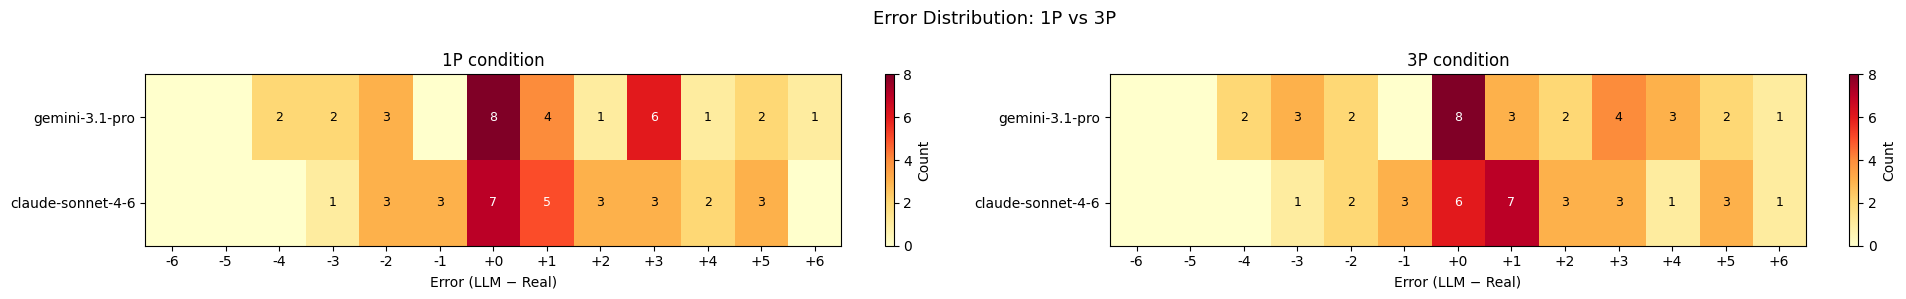

In [9]:
# ── Error distribution heatmap: 1P vs 3P side by side ──
import matplotlib.pyplot as plt

models_list = df["model"].unique()
error_range = range(-6, 7)

fig, axes = plt.subplots(1, 2, figsize=(20, max(3, len(models_list) * 0.8 + 1)))

for ax_idx, cond in enumerate(CONDITIONS):
    ax = axes[ax_idx]
    heatmap_data = []
    for model_name in models_list:
        mdf = df[(df["model"] == model_name) & (df["condition"] == cond) & df["error"].notna()]
        err_counts = Counter(mdf["error"].astype(int))
        row = [err_counts.get(e, 0) for e in error_range]
        heatmap_data.append(row)

    heatmap_array = np.array(heatmap_data)
    vmax = max(1, heatmap_array.max())
    im = ax.imshow(heatmap_array, aspect='auto', cmap='YlOrRd', vmin=0, vmax=vmax)
    ax.set_xticks(range(len(list(error_range))))
    ax.set_xticklabels([f"{e:+d}" for e in error_range])
    ax.set_yticks(range(len(models_list)))
    ax.set_yticklabels(models_list)
    ax.set_xlabel("Error (LLM \u2212 Real)")
    ax.set_title(f"{cond} condition")

    for i in range(len(models_list)):
        for j in range(len(list(error_range))):
            val = heatmap_array[i, j]
            if val > 0:
                ax.text(j, i, str(val), ha='center', va='center',
                        color='white' if val > vmax * 0.5 else 'black', fontsize=9)

    plt.colorbar(im, ax=ax, label="Count")

plt.suptitle('Error Distribution: 1P vs 3P', fontsize=13)
plt.tight_layout()
plt.show()

## Response distribution: 1P vs 3P vs Ground Truth

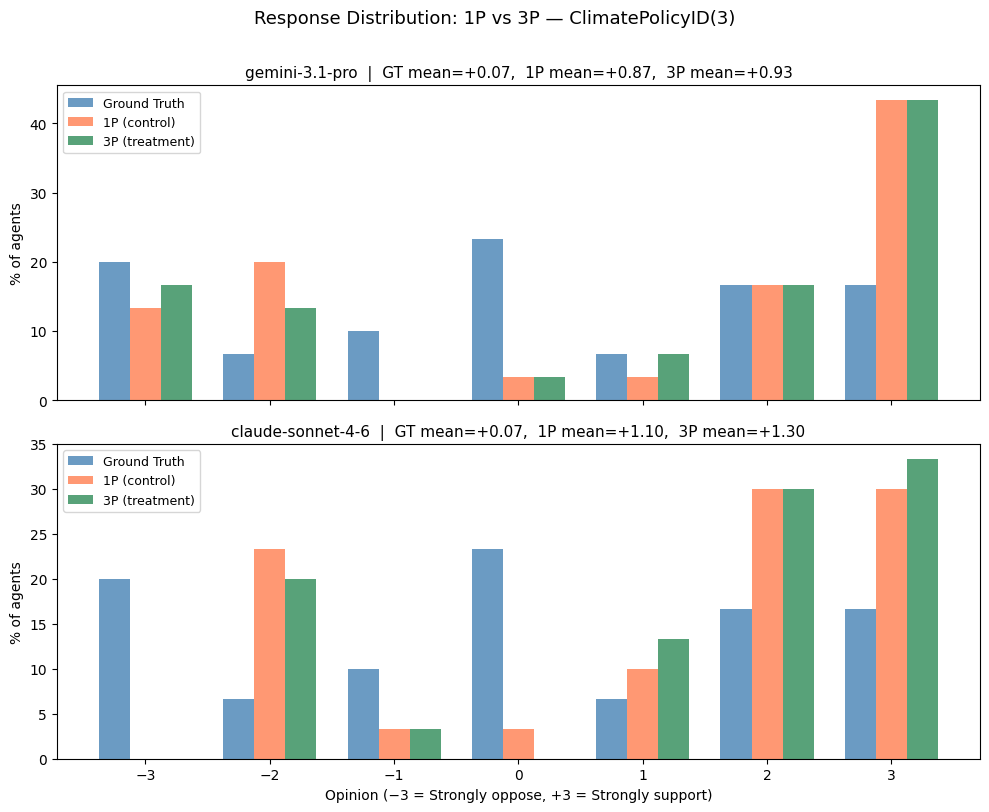

In [10]:
# ── Response distribution per model: 1P vs 3P vs Ground Truth ──
scale_values = list(range(-3, 4))
n_models = len(models_list)

fig, axes = plt.subplots(n_models, 1, figsize=(10, 4 * n_models), sharex=True)
if n_models == 1:
    axes = [axes]

# Ground truth distribution
gt_dist = Counter(gt_values)
gt_pcts = [gt_dist.get(v, 0) / len(gt_values) * 100 for v in scale_values]

bar_width = 0.25
x = np.array(scale_values)

for idx, model_name in enumerate(models_list):
    ax = axes[idx]

    # 1P distribution
    mdf_1p = df[(df["model"] == model_name) & (df["condition"] == "1P") & df["llm_numeric"].notna()]
    dist_1p = Counter(mdf_1p["llm_numeric"].astype(int))
    n_1p = len(mdf_1p)
    pcts_1p = [dist_1p.get(v, 0) / max(n_1p, 1) * 100 for v in scale_values]

    # 3P distribution
    mdf_3p = df[(df["model"] == model_name) & (df["condition"] == "3P") & df["llm_numeric"].notna()]
    dist_3p = Counter(mdf_3p["llm_numeric"].astype(int))
    n_3p = len(mdf_3p)
    pcts_3p = [dist_3p.get(v, 0) / max(n_3p, 1) * 100 for v in scale_values]

    ax.bar(x - bar_width, gt_pcts, bar_width, label='Ground Truth', color='steelblue', alpha=0.8)
    ax.bar(x, pcts_1p, bar_width, label='1P (control)', color='coral', alpha=0.8)
    ax.bar(x + bar_width, pcts_3p, bar_width, label='3P (treatment)', color='seagreen', alpha=0.8)

    mean_1p = mdf_1p["llm_numeric"].mean() if n_1p > 0 else float('nan')
    mean_3p = mdf_3p["llm_numeric"].mean() if n_3p > 0 else float('nan')
    ax.set_title(f"{model_name}  |  GT mean={gt_mean:+.2f},  1P mean={mean_1p:+.2f},  3P mean={mean_3p:+.2f}",
                 fontsize=11)
    ax.set_ylabel('% of agents')
    ax.set_xticks(scale_values)
    ax.legend(loc='upper left', fontsize=9)

axes[-1].set_xlabel('Opinion (\u22123 = Strongly oppose, +3 = Strongly support)')
plt.suptitle(f'Response Distribution: 1P vs 3P — {POLICY_ID}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Per-agent scatter: 1P vs 3P

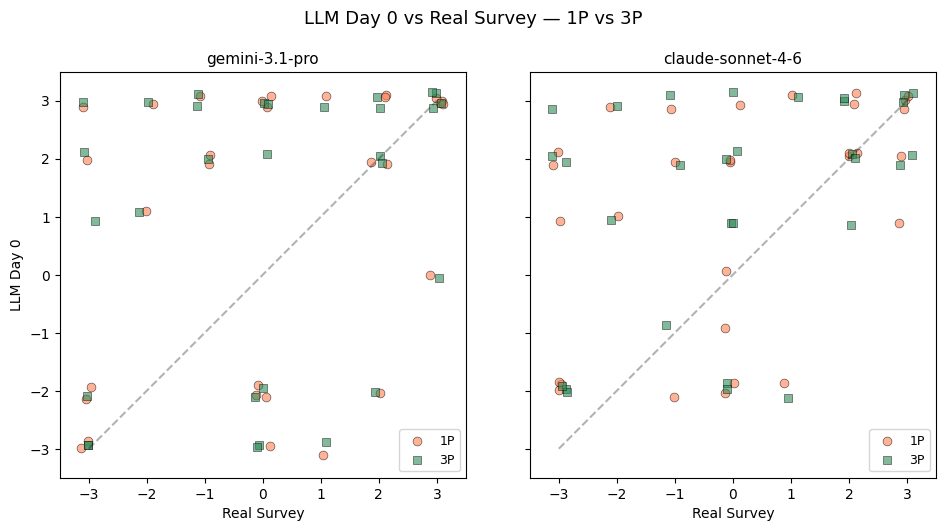

In [11]:
# ── Scatter: LLM vs Real, 1P (coral) vs 3P (green) ──
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True, sharex=True)
if n_models == 1:
    axes = [axes]

rng = np.random.default_rng(42)

for idx, model_name in enumerate(models_list):
    ax = axes[idx]

    for cond, color, marker, label in [("1P", "coral", "o", "1P"), ("3P", "seagreen", "s", "3P")]:
        mdf = df[(df["model"] == model_name) & (df["condition"] == cond) & df["llm_numeric"].notna()]
        jitter_x = rng.uniform(-0.15, 0.15, size=len(mdf))
        jitter_y = rng.uniform(-0.15, 0.15, size=len(mdf))
        ax.scatter(mdf["real_numeric"] + jitter_x, mdf["llm_numeric"] + jitter_y,
                   alpha=0.6, s=40, edgecolors='black', linewidths=0.5,
                   color=color, marker=marker, label=label)

    ax.plot([-3, 3], [-3, 3], 'k--', alpha=0.3)
    ax.set_title(model_name, fontsize=11)
    ax.set_xlabel('Real Survey')
    if idx == 0:
        ax.set_ylabel('LLM Day 0')
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_xticks(range(-3, 4))
    ax.set_yticks(range(-3, 4))
    ax.set_aspect('equal')
    ax.legend(fontsize=9)

plt.suptitle('LLM Day 0 vs Real Survey — 1P vs 3P', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Save results

In [12]:
# ── Save ──
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = f"../data/output/experiments/{timestamp}_3p_experiment"
os.makedirs(out_dir, exist_ok=True)

df.to_csv(f"{out_dir}/per_agent_results.csv", index=False)
summary.to_csv(f"{out_dir}/model_summary.csv", index=False)

print(f"Results saved to {out_dir}/")
print()
print(summary[display_cols].to_string(index=False))

Results saved to ../data/output/experiments/20260418_223858_3p_experiment/

            Model Condition  n  Mean LLM  Exact %  Ordinal  Mean Error      MAE  Direction %  Spearman ρ
claude-sonnet-4-6        1P 30  1.100000 0.233333 0.694444    1.033333 1.833333     0.533333    0.438055
claude-sonnet-4-6        3P 30  1.300000 0.200000 0.683333    1.233333 1.900000     0.500000    0.357478
   gemini-3.1-pro        1P 30  0.866667 0.266667 0.644444    0.800000 2.133333     0.433333    0.353132
   gemini-3.1-pro        3P 30  0.933333 0.266667 0.622222    0.866667 2.266667     0.400000    0.300590


## Notes

**What to look for:**

1. **\u0394 Mean Error < 0** — 3P reduces pro-climate bias (moves mean error closer to 0)
2. **\u0394 MAE < 0** — 3P improves absolute accuracy
3. **\u0394 Spearman > 0** — 3P preserves or improves ranking of agents
4. **Wilcoxon p < 0.05** — the MAE difference is statistically significant (paired test)
5. **Response distribution** — 3P uses more of the negative end of the scale (the main gap in 1P)

**Key design decisions:**
- Same 30 agents + seed 44 as notebook 11 for comparability
- `send_chat()` called directly to inject custom prompts without modifying source code
- System + user prompt changed together (single treatment) per ELEPHANT/SimToM methodology
- `parse_letter_response()` from source ensures consistent response parsing across conditions